In [ ]:
# 读取sc文件，计算不同的指标与链长或者界面残基个数之间的关系

In [1]:
import os
import pandas as pd
from Bio.PDB.PDBParser import PDBParser
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# 参数

minimized_dir = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/minimized"
minimized_sc_path = "./minimized-betajan25-nopackinput.sc"
cms_path = "./cms_results.csv"
export_dir = "./"
os.makedirs(export_dir, exist_ok=True)

# 读取 minimized 中的 pdb 文件，建立 "pdb_id(前4位) -> L链长度" 映射
pdb_l_len = {}
for pdb in os.listdir(minimized_dir):
    if not pdb.endswith('.pdb'):
        continue

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb[:-4], os.path.join(minimized_dir, pdb))

    l_len = None
    for model in structure:
        if 'L' in model:
            l_len = len(model['L'])
            break

    if l_len is None:
        continue

    pdb_id = pdb[:4].lower()
    if pdb_id in pdb_l_len and pdb_l_len[pdb_id] != l_len:
        print(f"Warning: {pdb_id} has inconsistent L-chain lengths: {pdb_l_len[pdb_id]} vs {l_len}")
    pdb_l_len[pdb_id] = l_len

print(f"Loaded L-chain lengths for {len(pdb_l_len)} PDB IDs.")

# 读取 minimized 和 cms
df_minimized = pd.read_csv(minimized_sc_path, skiprows=1, sep=r'\s+')
df_cms = pd.read_csv(cms_path)
df_cms['target'] = df_cms['PDB'].str[:4].str.lower()

# 

# 保留 description 原值，便于导出时保留该行标识
df_minimized['description_raw'] = df_minimized['description']

df_minimized['pdb_id'] = df_minimized['description'].str[:4].str.lower()

# 若原始行存在任一 NaN：原始数据行（除 description 标识列外）全部置空
# 并在后续将该行派生指标也统一置空

source_nan_mask_minimized = df_minimized.drop(columns=['pdb_id', 'description_raw']).isna().any(axis=1)


df_minimized['source_nan_row'] = source_nan_mask_minimized


if source_nan_mask_minimized.any():
    nullable_cols_minimized = [
        col for col in df_minimized.columns
        if col not in ['pdb_id', 'description', 'description_raw', 'source_nan_row']
    ]
    df_minimized.loc[source_nan_mask_minimized, nullable_cols_minimized] = pd.NA


# 计算当前保留数据上的归一化指标（保留当前输出的所有指标）
df_minimized['L_chain_length'] = df_minimized['pdb_id'].map(pdb_l_len)

for df in [df_minimized]:
    df['dSASA_int_per_res'] = round(df['dSASA_int'] / df['L_chain_length'], 3)
    df['dSASA_int_per_intres'] = round(df['dSASA_int'] / df['nres_int'], 3)
    df['Hbond_per_res'] = round(df['hbonds_int'] / df['L_chain_length'], 3)
    df['delta_unsatHbonds_per_res'] = round(df['delta_unsatHbonds'] / df['L_chain_length'], 3)
    df['delta_unsatHbonds_per_intres'] = round(df['delta_unsatHbonds'] / df['nres_int'], 3)

# 含 NaN 源行的派生指标统一置空
derived_cols = [
    'dSASA_int_per_res',
    'dSASA_int_per_intres',
    'Hbond_per_res',
    'delta_unsatHbonds_per_res',
    'delta_unsatHbonds_per_intres',
]
df_minimized.loc[df_minimized['source_nan_row'], derived_cols] = pd.NA

# 按 pdb_id 字符串升序排序
df_minimized = df_minimized.sort_values('pdb_id', kind='stable').reset_index(drop=True)

# 添加target列，值为PDB的前四位字符小写
df_minimized['target'] = df_minimized['pdb_id']

print(f"Ground truth rows after filter: {len(df_minimized)}")
print(f"Rows with source NaN : {int(df_minimized['source_nan_row'].sum())}")
df_minimized.to_csv(os.path.join(export_dir, 'minimized_betajan25_nopackinput_processed.csv'), index=False)

Loaded L-chain lengths for 170 PDB IDs.
Ground truth rows after filter: 170
Rows with source NaN : 0


In [5]:
df_minimized = pd.read_csv("./minimized_betajan25_nopackinput_processed.csv")
df_cms = pd.read_csv("./cms_results.csv")
df_cms['target'] = df_cms['PDB'].str[:4].str.lower()
# 按照target合并df_minimized和df_cms
df_merged = pd.merge(df_minimized, df_cms, on='target', how='outer', suffixes=('_minimized', '_cms'))
df_merged.to_csv('merged_minimized_cms.csv', index=False)

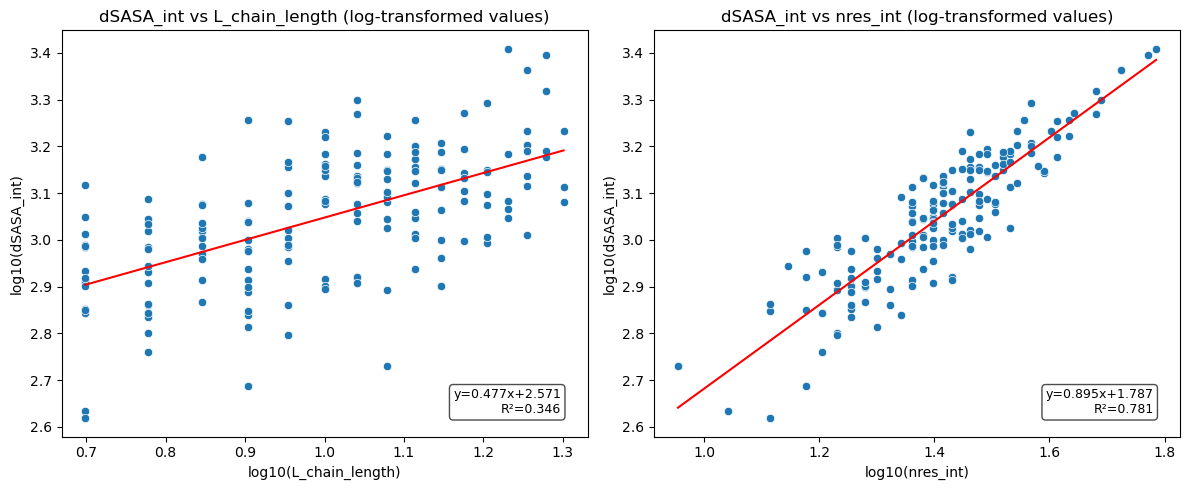

/QIN/junjiechen/miniforge3/envs/Dpepalign/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


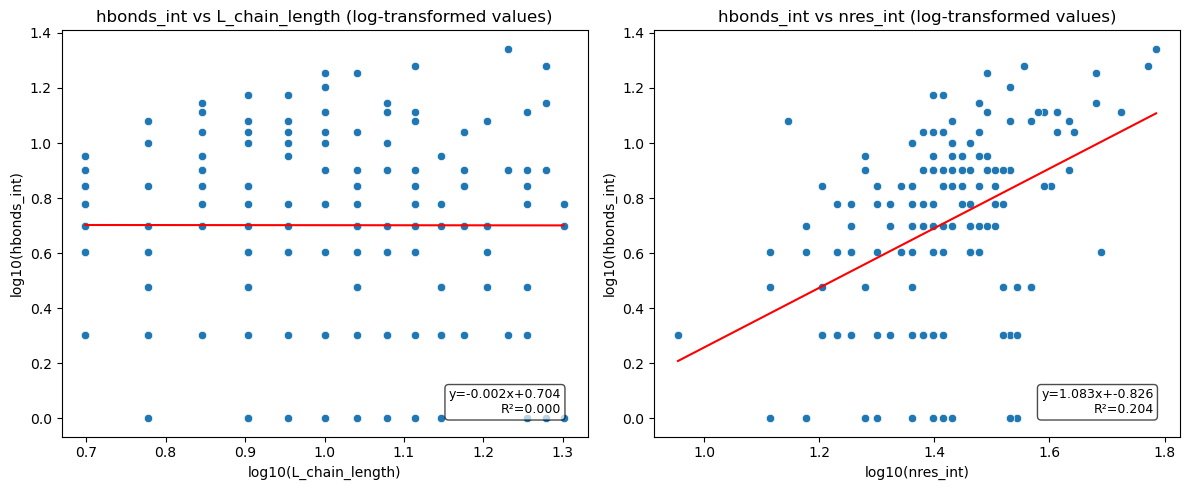

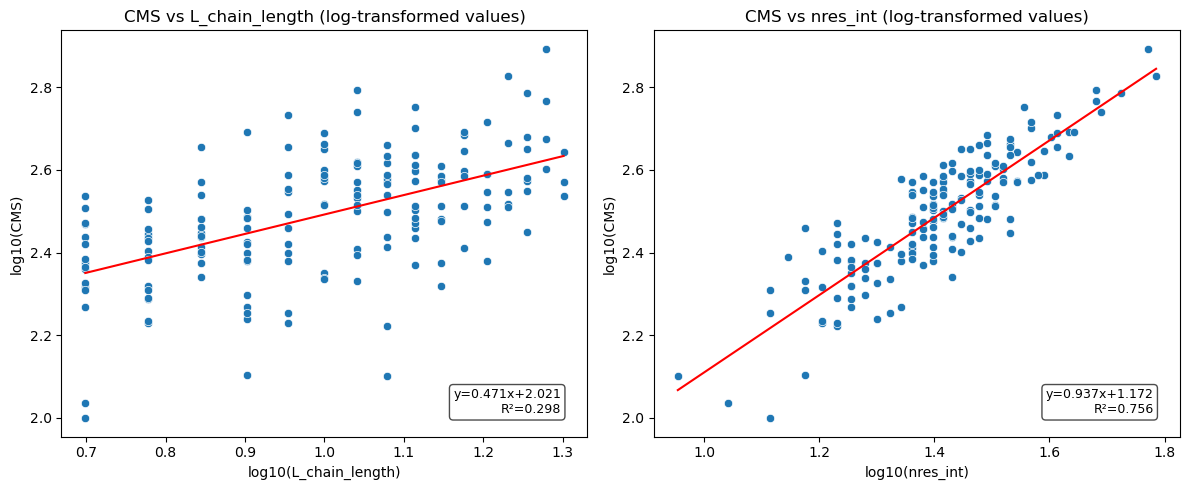

In [6]:
# 绘制指标与链长(L_chain_length)或者界面残基个数(nres_int)之间的关系图，横纵坐标取log10，考虑的指标包括: dSASA_int, hbonds_int, delta_unsatHbonds, total_score
df = pd.read_csv('merged_minimized_cms.csv')
metrics = ['dSASA_int', 'hbonds_int', 'CMS']
for metric in metrics:
    # copy to avoid mutating original dataframe
    df_plot = df.copy()

    # compute log10 values; set non-positive to NaN so they are excluded
    df_plot['log_L_chain_length'] = np.where(df_plot['L_chain_length'] > 0, np.log10(df_plot['L_chain_length']), np.nan)
    df_plot['log_nres_int'] = np.where(df_plot['nres_int'] > 0, np.log10(df_plot['nres_int']), np.nan)
    df_plot['log_metric'] = np.where(np.abs(df_plot[metric]) > 0, np.log10(np.abs(df_plot[metric])), np.nan)

    plt.figure(figsize=(12, 5))

    # 与链长的关系图（使用log值）
    plt.subplot(1, 2, 1)
    plot_df1 = df_plot[['log_L_chain_length', 'log_metric']].dropna()
    sns.scatterplot(data=plot_df1, x='log_L_chain_length', y='log_metric')
    plt.xlabel('log10(L_chain_length)')
    plt.ylabel(f'log10({metric})')
    plt.title(f'{metric} vs L_chain_length (log-transformed values)')

    # linear fit & annotation for subplot1
    if len(plot_df1) >= 2:
        x = plot_df1['log_L_chain_length'].values
        y = plot_df1['log_metric'].values
        coeffs = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ys = np.polyval(coeffs, xs)
        plt.plot(xs, ys, color='red', linewidth=1.5)
        y_pred = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        a, b = coeffs[0], coeffs[1]
        plt.gca().text(0.95, 0.05, f'y={a:.3f}x+{b:.3f}\nR²={r2:.3f}',
                       transform=plt.gca().transAxes, ha='right', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7), fontsize=9)

    # 与界面残基个数的关系图（使用log值）
    plt.subplot(1, 2, 2)
    plot_df2 = df_plot[['log_nres_int', 'log_metric']].dropna()
    sns.scatterplot(data=plot_df2, x='log_nres_int', y='log_metric')
    plt.xlabel('log10(nres_int)')
    plt.ylabel(f'log10({metric})')
    plt.title(f'{metric} vs nres_int (log-transformed values)')

    # linear fit & annotation for subplot2
    if len(plot_df2) >= 2:
        x2 = plot_df2['log_nres_int'].values
        y2 = plot_df2['log_metric'].values
        coeffs2 = np.polyfit(x2, y2, 1)
        xs2 = np.linspace(x2.min(), x2.max(), 200)
        ys2 = np.polyval(coeffs2, xs2)
        plt.plot(xs2, ys2, color='red', linewidth=1.5)
        y2_pred = np.polyval(coeffs2, x2)
        ss_res2 = np.sum((y2 - y2_pred) ** 2)
        ss_tot2 = np.sum((y2 - y2.mean()) ** 2)
        r2_2 = 1 - ss_res2 / ss_tot2 if ss_tot2 > 0 else np.nan
        a2, b2 = coeffs2[0], coeffs2[1]
        plt.gca().text(0.95, 0.05, f'y={a2:.3f}x+{b2:.3f}\nR²={r2_2:.3f}',
                       transform=plt.gca().transAxes, ha='right', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7), fontsize=9)

    plt.tight_layout()
    plt.show()


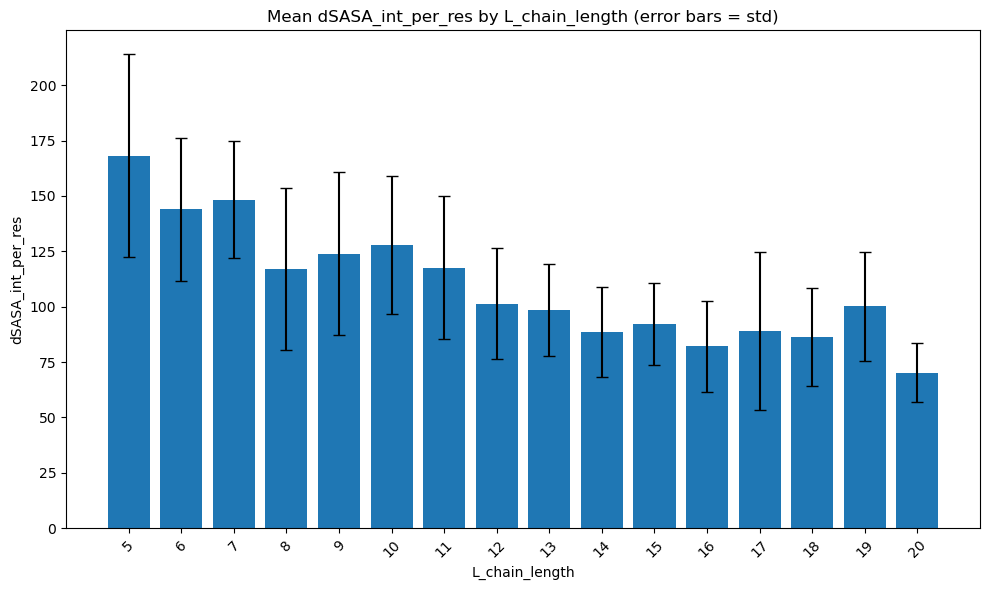

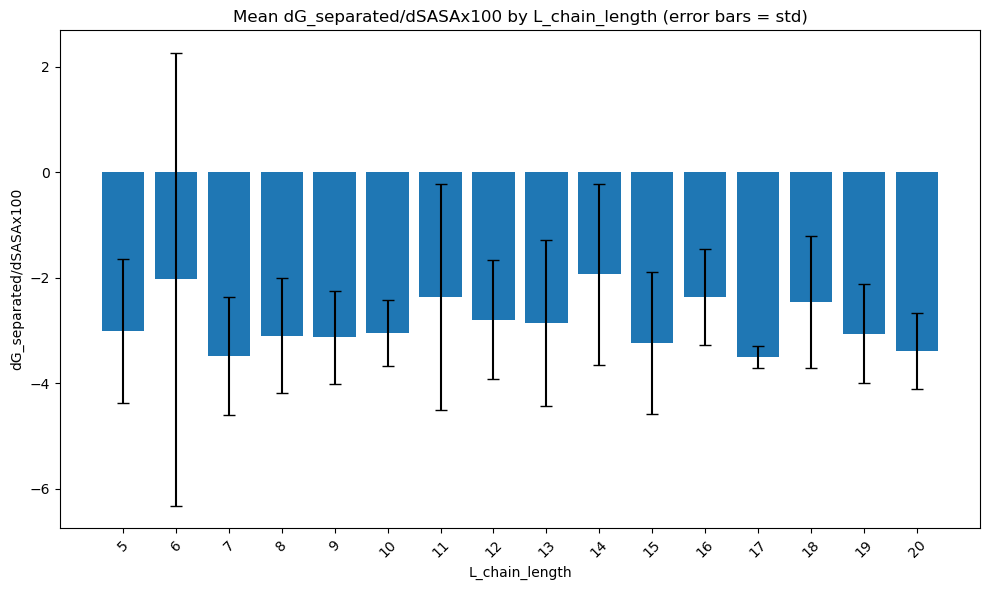

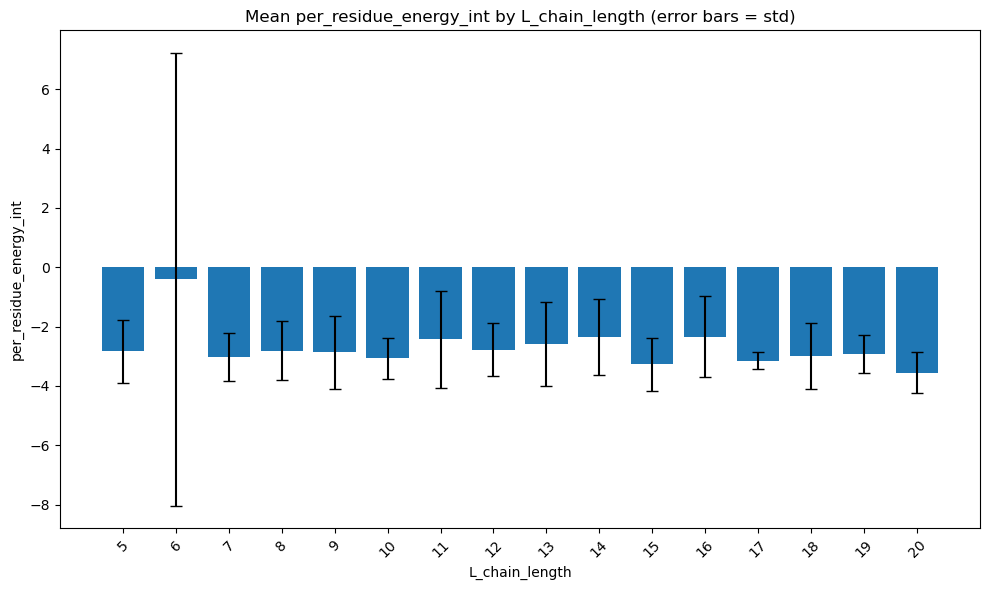

In [7]:
# 绘制dSASA_int_per_res，dG_separated/dSASA和energy_per_int_res与链长的关系，横坐标为链长，纵坐标为指标，绘制直方图
metrics = ['dSASA_int_per_res', 'dG_separated/dSASAx100', 'per_residue_energy_int']
for metric in metrics:
    df_plot = df_minimized[['L_chain_length', metric]].dropna().copy()

    agg = (
        df_plot.groupby('L_chain_length')[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .sort_values('L_chain_length')
    )
    agg['std'] = agg['std'].fillna(0)

    plt.figure(figsize=(10, 6))
    plt.bar(agg['L_chain_length'].astype(str), agg['mean'], yerr=agg['std'], capsize=4, color='C0')
    plt.xlabel('L_chain_length')
    plt.ylabel(metric)
    plt.title(f'Mean {metric} by L_chain_length (error bars = std)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


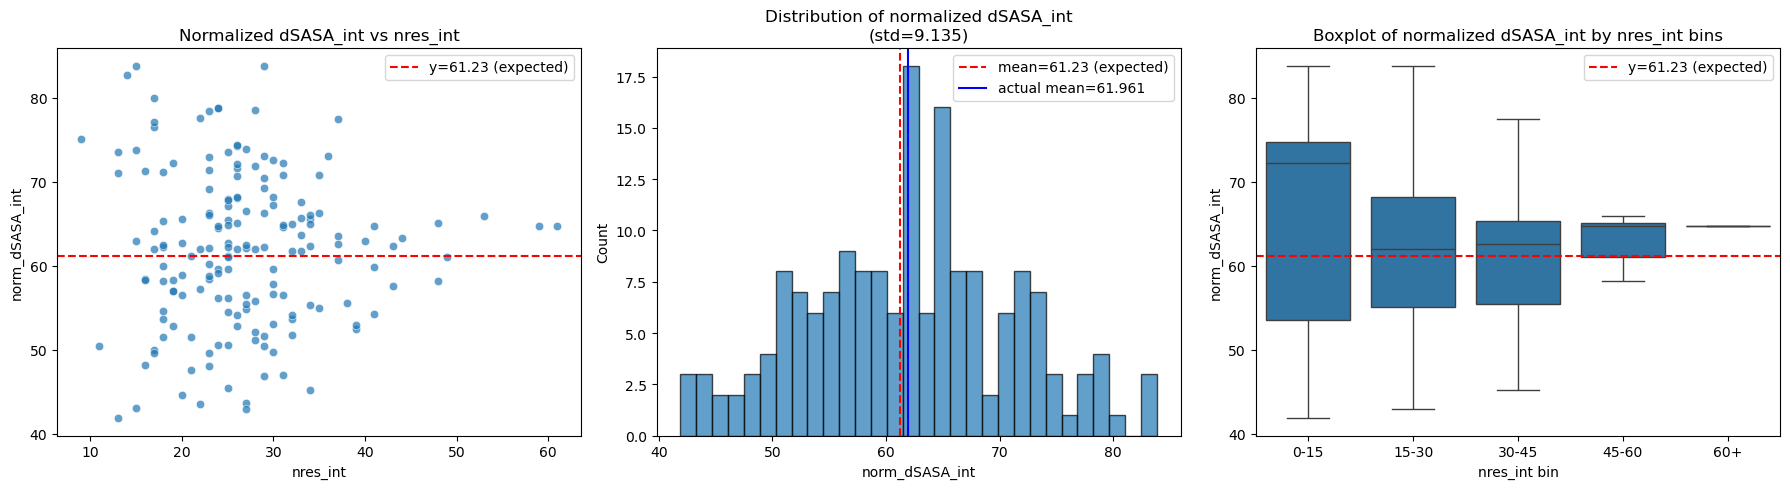

Normalized dSASA_int stats:
  mean = 61.9608
  std  = 9.1350
  min  = 41.8878
  max  = 83.8526


In [24]:
# log(dSASA_int) = 0.8948*log(nres_int) + 1.787, 相关系数为0.7806，现在根据这一公式，绘制dSASA_int的归一化指标与nres_int的关系

df_plot = df_minimized[['nres_int', 'dSASA_int','dSASA_int_per_intres','dSASA_int_per_res']].dropna().copy()



# 回归系数
slope = 0.8948
intercept = 1.787

# 根据公式计算预测值: log10(pred) = slope * log10(nres_int) + intercept
# 即 pred = 10^intercept * nres_int^slope
# df_plot['pred_dSASA_int'] = (10 ** intercept) * (df_plot['nres_int'] ** slope)
df_plot['norm_dSASA_int'] = df_plot['dSASA_int'] / (df_plot['nres_int'] ** slope)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1: 归一化指标 vs nres_int (散点图)
ax1 = axes[0]
sns.scatterplot(data=df_plot, x='nres_int', y='norm_dSASA_int', ax=ax1, alpha=0.7)
ax1.axhline(y=61.23, color='red', linestyle='--', label='y=61.23 (expected)')
ax1.set_xlabel('nres_int')
ax1.set_ylabel('norm_dSASA_int')
ax1.set_title('Normalized dSASA_int vs nres_int')
ax1.legend()


# 图2: 归一化指标的分布直方图
ax2 = axes[1]
ax2.hist(df_plot['norm_dSASA_int'], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=61.23, color='red', linestyle='--', label='mean=61.23 (expected)')
ax2.axvline(x=df_plot['norm_dSASA_int'].mean(), color='blue', linestyle='-', 
            label=f'actual mean={df_plot["norm_dSASA_int"].mean():.3f}')
ax2.set_xlabel('norm_dSASA_int')
ax2.set_ylabel('Count')
ax2.set_title(f'Distribution of normalized dSASA_int\n(std={df_plot["norm_dSASA_int"].std():.3f})')
ax2.legend()

# 图3: 归一化指标与nres_int的箱线图，将nres_int分成几个区间，观察不同区间的归一化指标分布情况
df_plot['nres_int_bin'] = pd.cut(df_plot['nres_int'], bins=[0, 15, 30, 45, 60, np.inf], labels=['0-15', '15-30', '30-45', '45-60', '60+'])
ax3 = axes[2]
sns.boxplot(data=df_plot, x='nres_int_bin', y='norm_dSASA_int', ax=ax3)
ax3.set_xlabel('nres_int bin')
ax3.set_ylabel('norm_dSASA_int')
ax3.set_title('Boxplot of normalized dSASA_int by nres_int bins')
ax3.axhline(y=61.23, color='red', linestyle='--', label='y=61.23 (expected)')
ax3.legend()

plt.tight_layout()
plt.show()

# 打印统计摘要
print(f"Normalized dSASA_int stats:")
print(f"  mean = {df_plot['norm_dSASA_int'].mean():.4f}")
print(f"  std  = {df_plot['norm_dSASA_int'].std():.4f}")
print(f"  min  = {df_plot['norm_dSASA_int'].min():.4f}")
print(f"  max  = {df_plot['norm_dSASA_int'].max():.4f}")

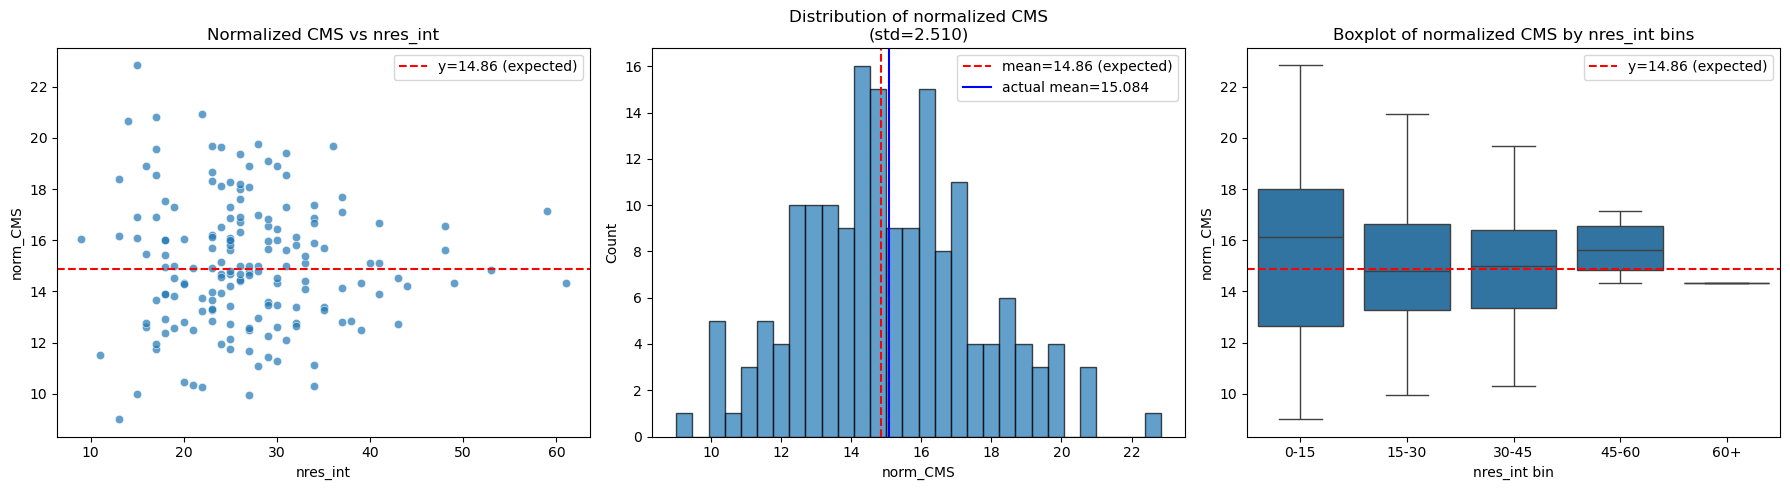

Normalized CMS stats:
  mean = 15.0838
  std  = 2.5104
  min  = 9.0137
  max  = 22.8324


In [8]:
# 对cms结果也进行同样的分析，绘制CMS与链长和界面残基个数的关系图，横纵坐标取log10


df_plot = df[['nres_int', 'CMS']].dropna().copy()


# 回归系数
slope = 0.937
intercept = 1.172

# 根据公式计算预测值: log10(pred) = slope * log10(nres_int) + intercept
# 即 pred = 10^intercept * nres_int^slope
# df_plot['pred_dSASA_int'] = (10 ** intercept) * (df_plot['nres_int'] ** slope)
df_plot['norm_CMS'] = df_plot['CMS'] / (df_plot['nres_int'] ** slope)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1: 归一化指标 vs nres_int (散点图)
ax1 = axes[0]
sns.scatterplot(data=df_plot, x='nres_int', y='norm_CMS', ax=ax1, alpha=0.7)
ax1.axhline(y=14.86, color='red', linestyle='--', label='y=14.86 (expected)')
ax1.set_xlabel('nres_int')
ax1.set_ylabel('norm_CMS')
ax1.set_title('Normalized CMS vs nres_int')
ax1.legend()


# 图2: 归一化指标的分布直方图
ax2 = axes[1]
ax2.hist(df_plot['norm_CMS'], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=14.86, color='red', linestyle='--', label='mean=14.86 (expected)')
ax2.axvline(x=df_plot['norm_CMS'].mean(), color='blue', linestyle='-', 
            label=f'actual mean={df_plot["norm_CMS"].mean():.3f}')
ax2.set_xlabel('norm_CMS')
ax2.set_ylabel('Count')
ax2.set_title(f'Distribution of normalized CMS\n(std={df_plot["norm_CMS"].std():.3f})')
ax2.legend()

# 图3: 归一化指标与nres_int的箱线图，将nres_int分成几个区间，观察不同区间的归一化指标分布情况
df_plot['nres_int_bin'] = pd.cut(df_plot['nres_int'], bins=[0, 15, 30, 45, 60, np.inf], labels=['0-15', '15-30', '30-45', '45-60', '60+'])
ax3 = axes[2]
sns.boxplot(data=df_plot, x='nres_int_bin', y='norm_CMS', ax=ax3)
ax3.set_xlabel('nres_int bin')
ax3.set_ylabel('norm_CMS')
ax3.set_title('Boxplot of normalized CMS by nres_int bins')
ax3.axhline(y=14.86, color='red', linestyle='--', label='y=14.86 (expected)')
ax3.legend()

plt.tight_layout()
plt.show()

# 打印统计摘要
print(f"Normalized CMS stats:")
print(f"  mean = {df_plot['norm_CMS'].mean():.4f}")
print(f"  std  = {df_plot['norm_CMS'].std():.4f}")
print(f"  min  = {df_plot['norm_CMS'].min():.4f}")
print(f"  max  = {df_plot['norm_CMS'].max():.4f}")

/tmp/ipykernel_2854307/567169228.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_2854307/567169228.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


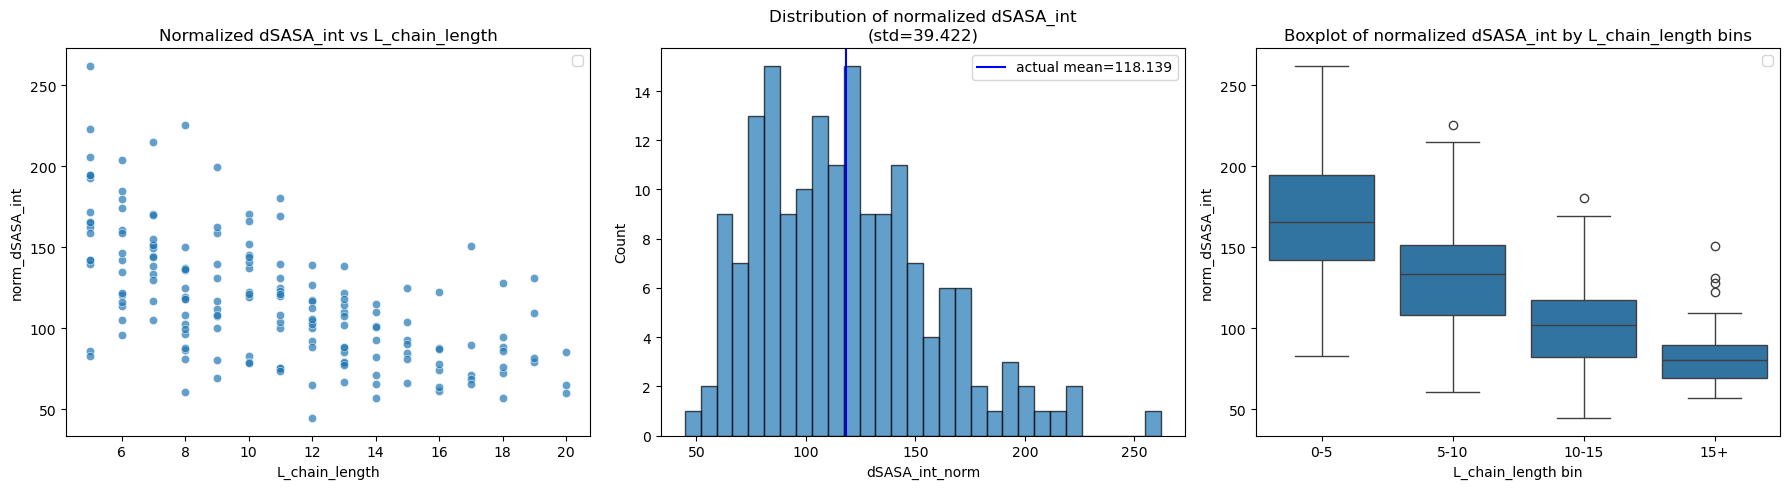

Normalized dSASA_int stats:
  mean = 118.1395
  std  = 39.4223
  min  = 44.7178
  max  = 262.2742


In [27]:
# 按照先前仅根据L_chain_length归一化的指标，绘制dSASA_int_per_res与nres_int的关系图，横坐标为nres_int，纵坐标为dSASA_int_per_res，并绘制dSASA_int_per_res的分布直方图

df_plot = df_minimized[['L_chain_length', 'dSASA_int']].dropna().copy()



df_plot['norm_dSASA_int'] = df_plot['dSASA_int'] / df_plot['L_chain_length']


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1: 归一化指标 vs L_chain_length (散点图)
ax1 = axes[0]
sns.scatterplot(data=df_plot, x='L_chain_length', y='norm_dSASA_int', ax=ax1, alpha=0.7)
# ax1.axhline(y=61.23, color='red', linestyle='--', label='y=61.23 (expected)')
ax1.set_xlabel('L_chain_length')
ax1.set_ylabel('norm_dSASA_int')
ax1.set_title('Normalized dSASA_int vs L_chain_length')
ax1.legend()


# 图2: 归一化指标的分布直方图
ax2 = axes[1]
ax2.hist(df_plot['norm_dSASA_int'], bins=30, edgecolor='black', alpha=0.7)
# ax2.axvline(x=61.23, color='red', linestyle='--', label='mean=61.23 (expected)')
ax2.axvline(x=df_plot['norm_dSASA_int'].mean(), color='blue', linestyle='-', 
            label=f'actual mean={df_plot["norm_dSASA_int"].mean():.3f}')
ax2.set_xlabel('dSASA_int_norm')
ax2.set_ylabel('Count')
ax2.set_title(f'Distribution of normalized dSASA_int\n(std={df_plot["norm_dSASA_int"].std():.3f})')
ax2.legend()


# 图3: 归一化指标与nres_int的箱线图，将nres_int分成几个区间，观察不同区间的归一化指标分布情况
df_plot['L_chain_length_bin'] = pd.cut(df_plot['L_chain_length'], bins=[0, 5, 10, 15, np.inf], labels=['0-5', '5-10', '10-15', '15+'])
ax3 = axes[2]
sns.boxplot(data=df_plot, x='L_chain_length_bin', y='norm_dSASA_int', ax=ax3)
ax3.set_xlabel('L_chain_length bin')
ax3.set_ylabel('norm_dSASA_int')
ax3.set_title('Boxplot of normalized dSASA_int by L_chain_length bins')
# ax3.axhline(y=61.23, color='red', linestyle='--', label='y=61.23 (expected)')
ax3.legend()

plt.tight_layout()
plt.show()

# 打印统计摘要
print(f"Normalized dSASA_int stats:")
print(f"  mean = {df_plot['norm_dSASA_int'].mean():.4f}")
print(f"  std  = {df_plot['norm_dSASA_int'].std():.4f}")
print(f"  min  = {df_plot['norm_dSASA_int'].min():.4f}")
print(f"  max  = {df_plot['norm_dSASA_int'].max():.4f}")